MOUNT TO GOOGLE DRIVE WORKING DIRECTORY

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/NUS/Classes/CS5242/project

Mounted at /content/drive
/content/drive/MyDrive/NUS/Classes/CS5242/project


In [ ]:
# import importlib, types, sys

# # Patch missing 'imp' module for Python 3.12+ so autoreload works
# if "imp" not in sys.modules:
#     imp = types.ModuleType("imp")
#     imp.reload = importlib.reload
#     sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

LOAD DATASET

In [ ]:
from pathlib import Path

from src.utils import set_seed, get_device, make_loaders
from src.data_processing.data_processing import (
    load_mini_imagenet, explore_dataset, make_transforms,
    visualize_transforms,
)
from src.methods import classical_ml_experiment, train_finetune, train_from_scratch
from src.model import plot_training_curves, plot_representation_snapshots
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", message="Corrupt EXIF data")

# ── Configuration ──
SEED       = 24
IMG_SIZE   = 32
BATCH_SIZE = 512
USE_GPU    = True
SAVE_DIR   = Path("experiments")
LOCAL_DATA = Path("data")  # fast local SSD on the Colab VM
SUBSET = None #Limit dataset size per split (for quick testing
USE_AUG = False
BACKBONE = "convnext_tiny" #"convnext_tiny, resnet18"
MIX_MODE  = "none"   # "none", "mixup", or "cutmix"
MIX_ALPHA = 0.2      # Beta distribution parameter for mix regularization

eda_path = SAVE_DIR / "eda"

set_seed(SEED)
device = get_device(USE_GPU)
print(f"Device: {device}")

In [2]:
# ── Load dataset (cached to local VM disk for speed) ──
ds = load_mini_imagenet(SUBSET, str(LOCAL_DATA))
print(f"Splits: {list(ds.keys())}")

Splits: ['train', 'validation', 'test']


EXPLORATORY DATA ANALYSIS

=== Split Sizes ===
         train: 50,000 images
    validation: 10,000 images
          test: 5,000 images


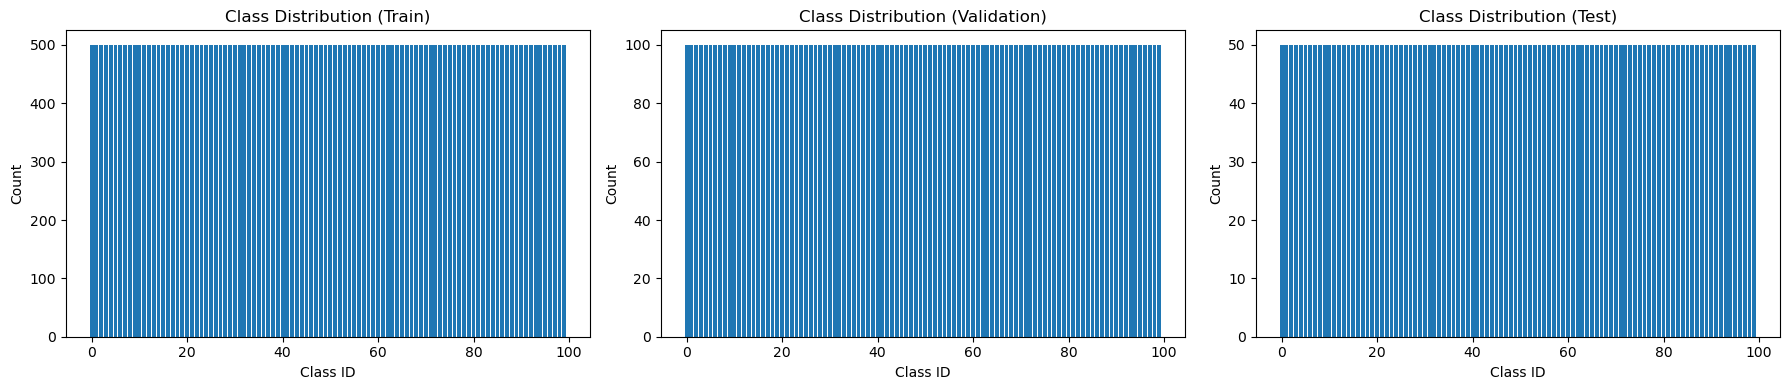

Saved class distribution plot (all splits).
Number of classes: 100
  Train — min=500 max=500
  Val   — min=100 max=100
  Test  — min=50 max=50
Saved image metadata (sampled 500 per split).
Saved visual inspection grid to: experiments/eda/visual_grid.png


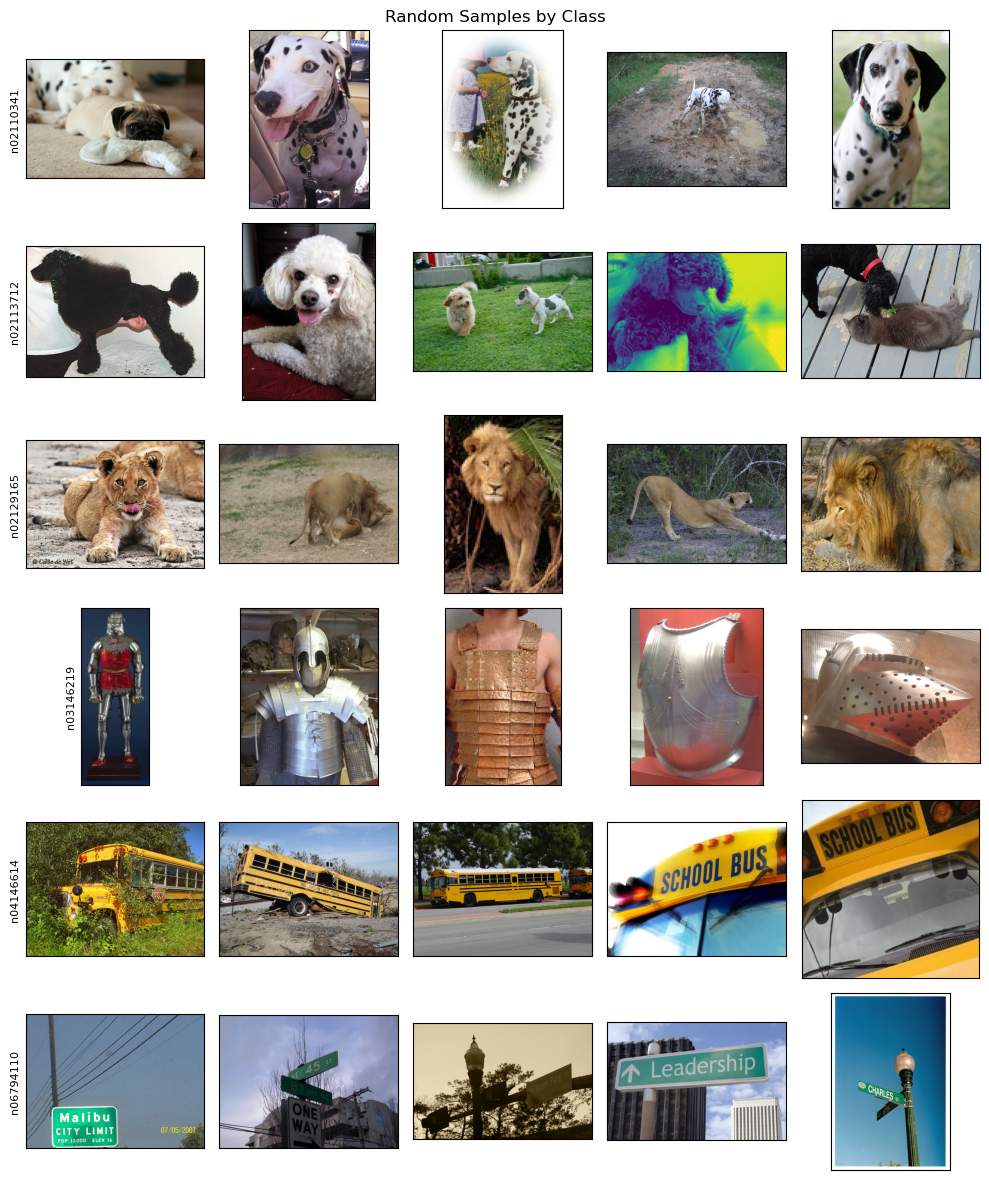

Computed mean/std (sampled 5000): mean=[0.4732202  0.45187145 0.4089754 ], std=[0.2849122  0.2758142  0.28961954]


In [ ]:
explore_dataset(ds, save_dir=eda_path)

PROCESSING

Loaded normalisation stats from file.


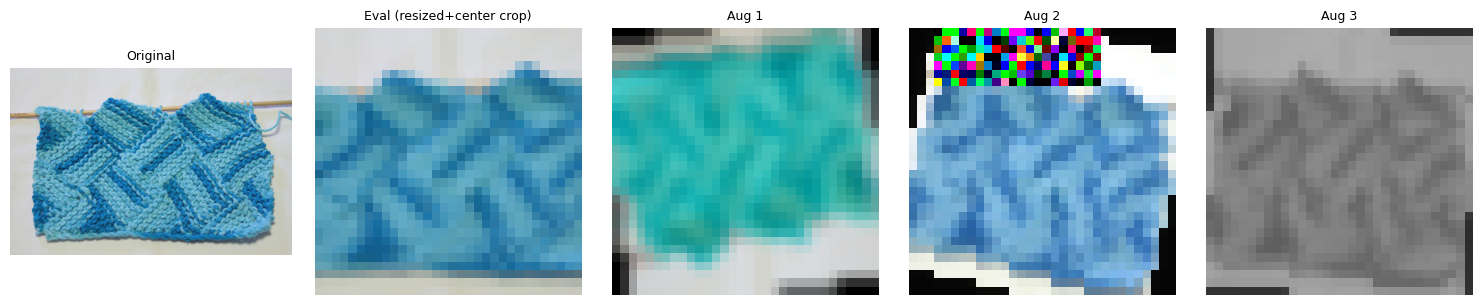

Saved transform visualization: experiments/transforms/transforms_00.png


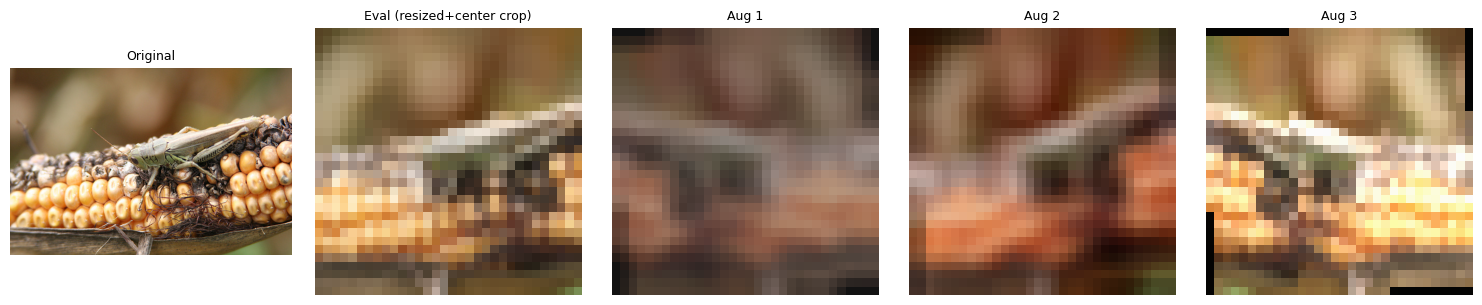

Saved transform visualization: experiments/transforms/transforms_01.png


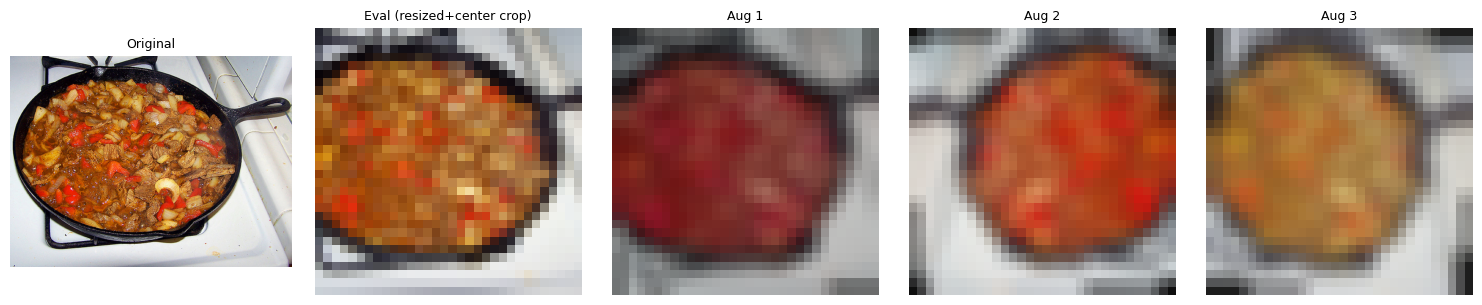

Saved transform visualization: experiments/transforms/transforms_02.png


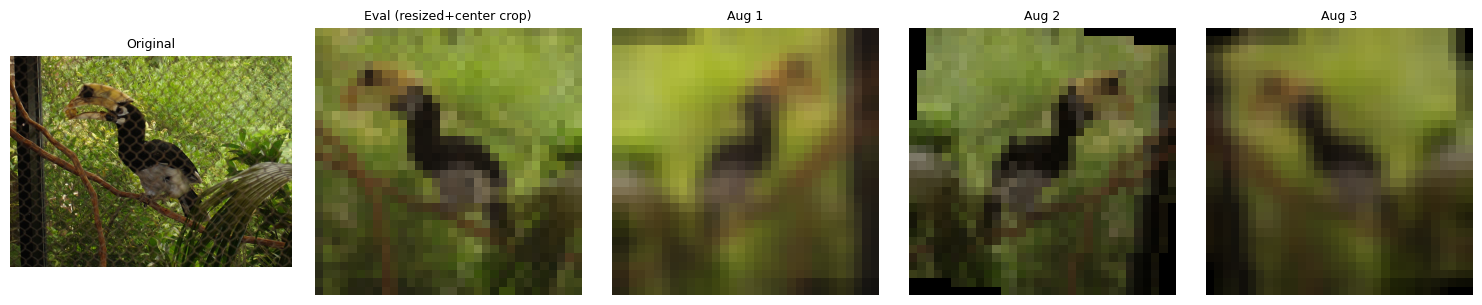

Saved transform visualization: experiments/transforms/transforms_03.png


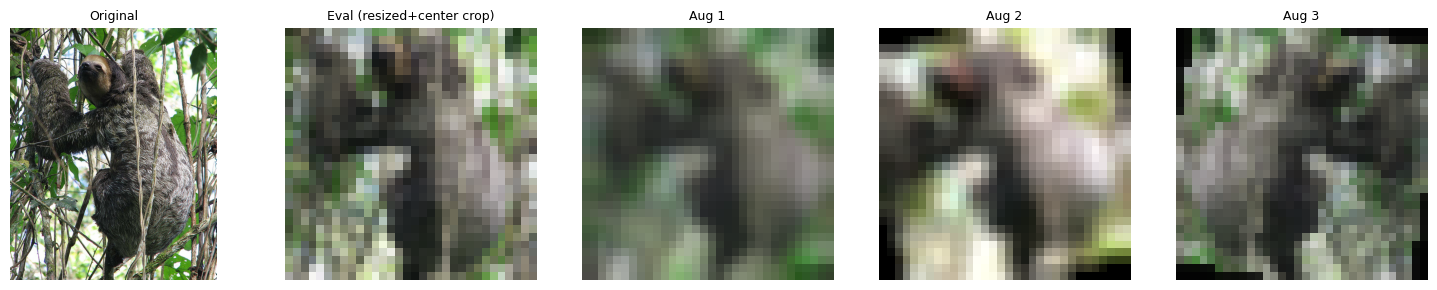

Saved transform visualization: experiments/transforms/transforms_04.png


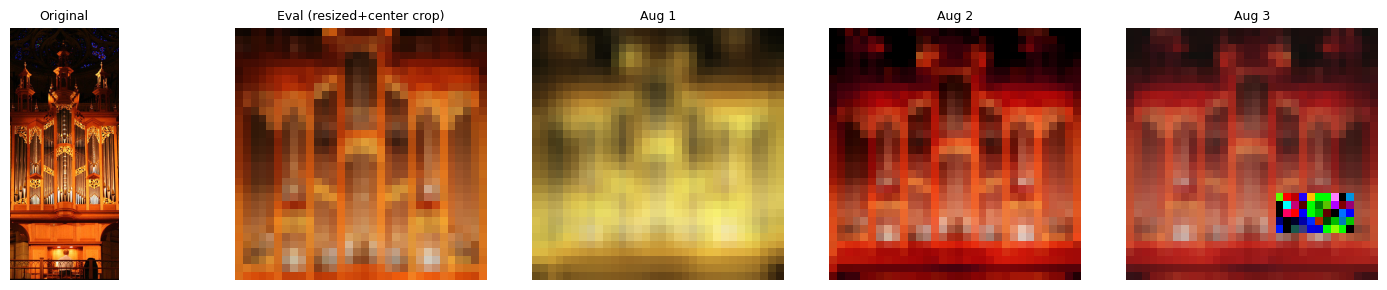

Saved transform visualization: experiments/transforms/transforms_05.png


In [3]:
import json
import numpy as np


mean_std_path = eda_path / "train_mean_std.json"
if mean_std_path.exists():
        with open(mean_std_path) as f:
            ms = json.load(f)
            mean = np.array(ms["mean"], dtype=np.float32)
            std  = np.array(ms["std"],  dtype=np.float32)
        print("Loaded normalisation stats from file.")

train_tf, eval_tf, tensor_only = make_transforms(img_size=IMG_SIZE,  mean=mean, std=std, use_aug=USE_AUG)

# Visualize original vs transformed images
visualize_transforms(
    ds["train"], train_tf, eval_tf, tensor_only,
    save_dir=SAVE_DIR / "transforms",
)

TRAINING WITH CLASSICAL ML

In [ ]:
classical_results = classical_ml_experiment(
    ds=ds,
    eval_tf=eval_tf,
    device=device,
    backbone=BACKBONE,
    clf_type="logreg",
    batch_size=BATCH_SIZE,
    save_dir=SAVE_DIR / BACKBONE / "classical_ml",
)

Extracting features (train / val / test) …
Feature extraction: 51.2s | train=(50000, 768)  val=(10000, 768)  test=(5000, 768)
Training LogisticRegression …


/home/nguyenhoa/miniconda3/envs/cs5242/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



  Classical ML Results (LogisticRegression)
  Val  accuracy : 0.4564
  Test accuracy : 0.4412
  Feature extraction time : 51.2s
  Classifier train time   : 274.0s
  Train/Val/Test samples   : 50000/10000/5000
Saved results → experiments/convnext_tiny/classical_ml/classical_ml_logreg.json


## FINETUNING

We compare several fine-tuning strategies: freezing the backbone, freezing early stages, full fine-tuning, and LoRA.

Each method supports optional **Mixup** or **CutMix** regularization:

- **Mixup** — blends two random images and their labels: `x = λ·x_a + (1-λ)·x_b`, `y = λ·y_a + (1-λ)·y_b`. The model learns smoother decision boundaries.
- **CutMix** — cuts a random patch from one image and pastes it onto another, blending labels proportionally to the patch area. Forces the model to attend to the full image.

Both are controlled by `mix_mode` (`"none"`, `"mixup"`, `"cutmix"`) and `mix_alpha` (Beta distribution parameter — higher = more mixing). Set `mix_mode="none"` to disable.

Freeze all feature stages; train classifier only

In [ ]:
policy = "backbone"
save_dir = Path(f"{SAVE_DIR}/{BACKBONE}/finetune/USE_AUG_{USE_AUG}/{policy}")

finetune_results, finetune_ckpt = train_finetune(
    ds=ds,
    train_tf=train_tf,
    eval_tf=eval_tf,
    device=device,
    backbone=BACKBONE,
    epochs=100,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    freeze_policy=policy,
    use_pretrained=True,
    save_dir=save_dir,
    mix_mode=MIX_MODE,
    mix_alpha=MIX_ALPHA,
)

In [ ]:
plot_training_curves(finetune_results, save_dir=save_dir)
plot_representation_snapshots(finetune_results["representation_snapshots"], save_dir=save_dir)

Freeze early stages; train last stage + classifier

In [ ]:
policy = "last_stage"
save_dir = Path(f"{SAVE_DIR}/{BACKBONE}/finetune/USE_AUG_{USE_AUG}/{policy}")

finetune_results, finetune_ckpt = train_finetune(
    ds=ds,
    train_tf=train_tf,
    eval_tf=eval_tf,
    device=device,
    backbone=BACKBONE,
    epochs=100,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    freeze_policy=policy,
    use_pretrained=True,
    save_dir=save_dir,
    patience=7,
    mix_mode=MIX_MODE,
    mix_alpha=MIX_ALPHA,
)

In [ ]:
plot_training_curves(finetune_results, save_dir=save_dir)
plot_representation_snapshots(finetune_results["representation_snapshots"], save_dir=save_dir)

Train all parameters

In [ ]:
policy = "none"
save_dir = Path(f"{SAVE_DIR}/{BACKBONE}/finetune/USE_AUG_{USE_AUG}/{policy}")

finetune_results, finetune_ckpt = train_finetune(
    ds=ds,
    train_tf=train_tf,
    eval_tf=eval_tf,
    device=device,
    backbone=BACKBONE,
    epochs=100,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    freeze_policy=policy,
    use_pretrained=True,
    save_dir=save_dir,
    patience=7,
    mix_mode=MIX_MODE,
    mix_alpha=MIX_ALPHA,
)

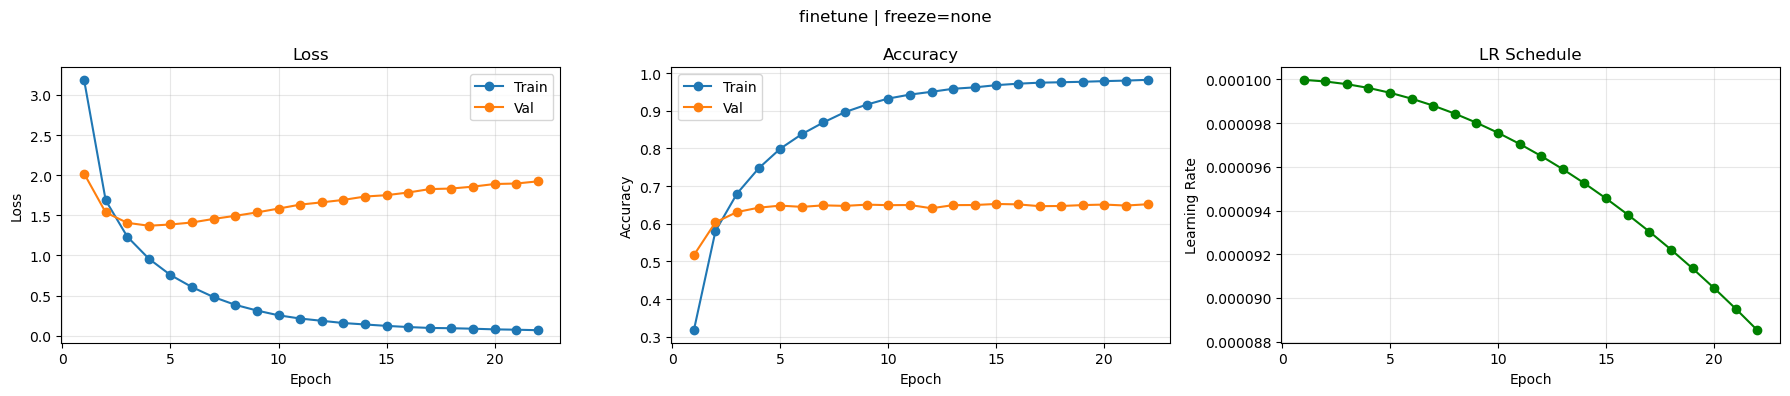

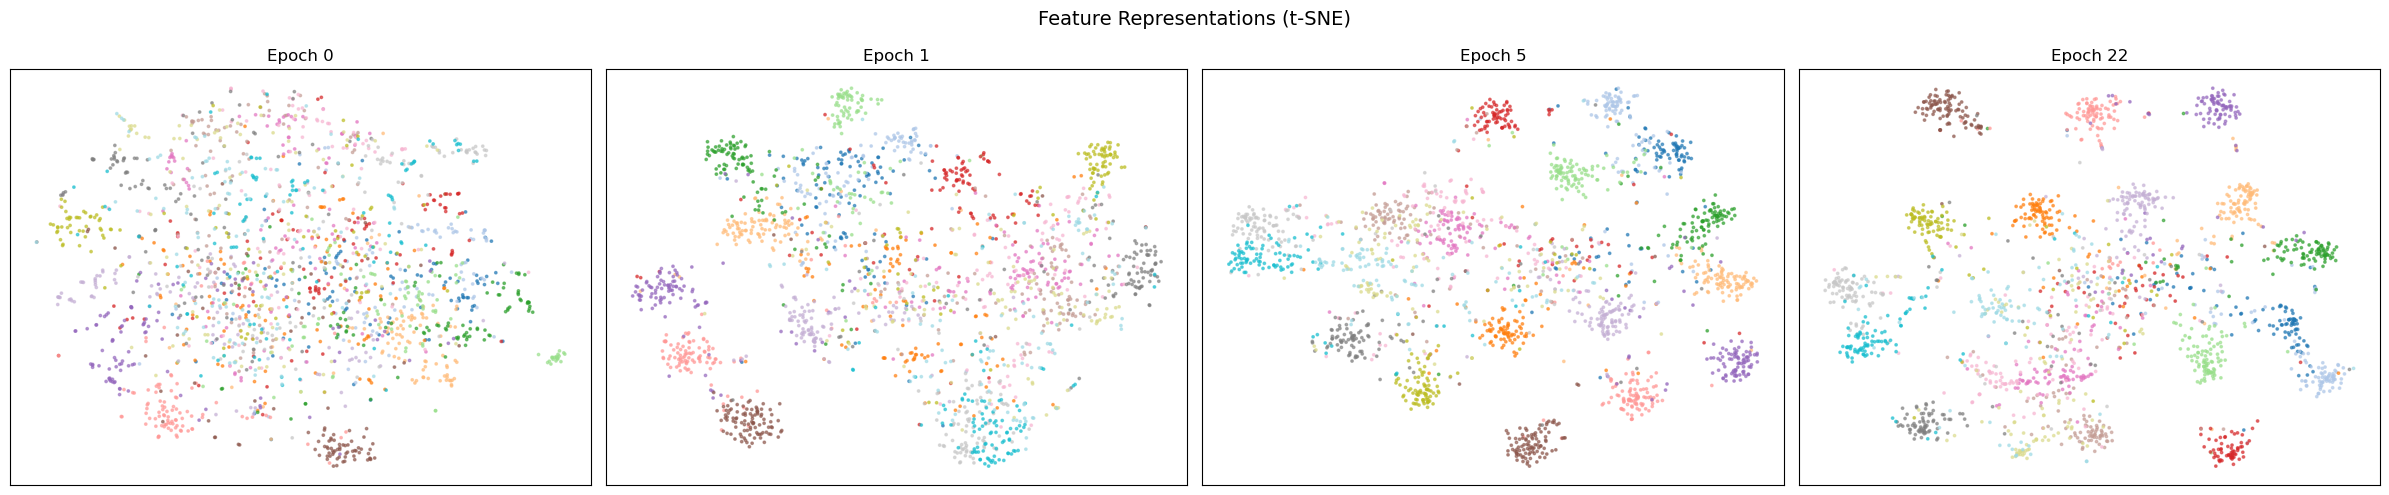

In [ ]:
plot_training_curves(finetune_results, save_dir=save_dir)
plot_representation_snapshots(finetune_results["representation_snapshots"], save_dir=save_dir)

## FINETUNING WITH LoRA (Low-Rank Adaptation)

LoRA injects small trainable low-rank matrices into the frozen backbone's Linear layers. Instead of updating the full weight matrix W, it learns a low-rank decomposition:

$$W' = W_{frozen} + B \cdot A \cdot \frac{\alpha}{r}$$

where A (in_features × rank) and B (rank × out_features) are the only trainable parameters per layer.

**Key properties:**
- **Fewer trainable params** than even `freeze_policy="backbone"` — only the LoRA matrices + classifier head are trained
- **Adapts the entire network** — unlike freezing, every targeted layer gets a small update
- **rank** controls capacity: lower rank = fewer params but less expressive; rank=8 is a common default
- **alpha** controls the scaling of the LoRA update relative to the original weights

In [ ]:
policy = "lora"
save_dir = Path(f"{SAVE_DIR}/{BACKBONE}/finetune/USE_AUG_{USE_AUG}/{policy}")

lora_results, lora_ckpt = train_finetune(
    ds=ds,
    train_tf=train_tf,
    eval_tf=eval_tf,
    device=device,
    backbone=BACKBONE,
    epochs=100,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    freeze_policy="lora",
    use_pretrained=True,
    save_dir=save_dir,
    patience=5,
    lora_rank=8,
    lora_alpha=16.0,
    mix_mode=MIX_MODE,
    mix_alpha=MIX_ALPHA,
)

In [ ]:
plot_training_curves(lora_results, save_dir=save_dir)
plot_representation_snapshots(lora_results["representation_snapshots"], save_dir=save_dir)

BUILDING DEEP LEARNING MODELS FROM SCRATCH

In [ ]:
scratch_results, scratch_ckpt = train_from_scratch(
    ds=ds,
    train_tf=train_tf,
    eval_tf=eval_tf,
    device=device,
    backbone="convnext_tiny",
    epochs=5,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    save_dir=SAVE_DIR / BACKBONE / "scratch",
    patience=7,
    mix_mode=MIX_MODE,
    mix_alpha=MIX_ALPHA,
)

In [ ]:
plot_training_curves(scratch_results, save_dir=SAVE_DIR / BACKBONE / "scratch")
plot_representation_snapshots(scratch_results["representation_snapshots"], save_dir=SAVE_DIR / BACKBONE / "scratch")